# Logistic Regression for Binary Classification

In this notebook, I implement logistic regression from scratch using NumPy.

The goal is to understand how a classification model works internally, including:

- The sigmoid function
- Logistic regression predictions
- Binary cross-entropy loss
- Gradient descent
- Decision boundaries
- Classification accuracy

This notebook is part of my machine learning from scratch journey after completing Week 3 of Andrew Ng's Machine Learning course.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## What is Classification?

In regression, the model predicts a continuous value.

In classification, the model predicts a category or class.

For binary classification, there are only two possible outputs:

- 0
- 1

Examples:

- Email: spam or not spam
- Tumor: malignant or benign
- Student: admitted or not admitted

Logistic regression is used for binary classification.

In [2]:
X = np.array([
    [34, 78],
    [30, 43],
    [35, 72],
    [60, 86],
    [79, 75],
    [75, 68],
    [50, 45],
    [45, 56],
    [80, 90],
    [62, 70],
    [20, 30],
    [25, 35],
    [90, 88],
    [85, 95],
    [55, 60]
])

y = np.array([0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1])

print(X.shape)
print(y.shape)

(15, 2)
(15,)


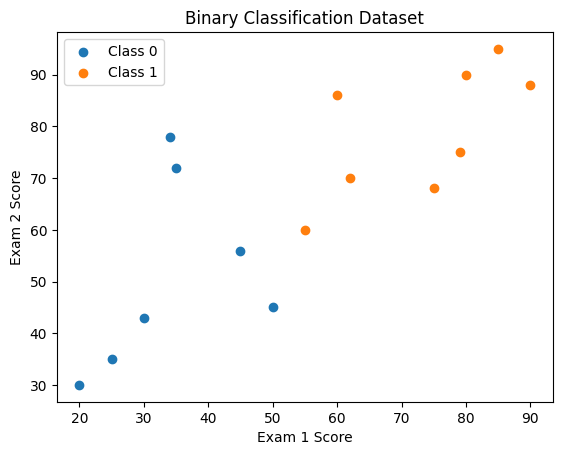

In [3]:
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], label="Class 0")
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], label="Class 1")

plt.xlabel("Exam 1 Score")
plt.ylabel("Exam 2 Score")
plt.title("Binary Classification Dataset")
plt.legend()
plt.show()

## Sigmoid Function

Linear regression can output any number, but classification needs a probability between 0 and 1.

The sigmoid function converts any real number into a value between 0 and 1.

The formula is:

$$
g(z) = \frac{1}{1 + e^{-z}}
$$

In logistic regression:

$$
z = w \cdot x + b
$$

and the prediction is:

$$
f_{w,b}(x) = g(w \cdot x + b)
$$

In [4]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

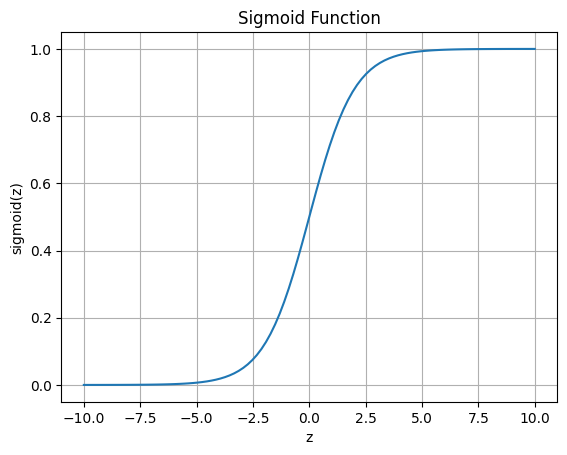

In [5]:
z = np.linspace(-10, 10, 100)
g = sigmoid(z)

plt.plot(z, g)
plt.xlabel("z")
plt.ylabel("sigmoid(z)")
plt.title("Sigmoid Function")
plt.grid(True)
plt.show()

## Logistic Regression Model

The model first calculates a linear value:

$$
z = Xw + b
$$

Then it passes that value through the sigmoid function:

$$
f = sigmoid(z)
$$

The output is interpreted as a probability.

For example:

- If the output is 0.85, the model is 85% confident the class is 1.
- If the output is 0.20, the model is closer to class 0.

To convert probability into a final class:

$$
prediction =
\begin{cases}
1 & \text{if } f \geq 0.5 \\
0 & \text{if } f < 0.5
\end{cases}
$$

In [6]:
m, n = X.shape

w = np.zeros(n)
b = 0

print(w)
print(b)

[0. 0.]
0


## Cost Function

Logistic regression uses binary cross-entropy loss instead of mean squared error.

The cost function is:

$$
J(w,b) = -\frac{1}{m} \sum_{i=1}^{m}
\left[
y^{(i)}\log(f^{(i)}) + (1-y^{(i)})\log(1-f^{(i)})
\right]
$$

This cost heavily penalizes confident wrong predictions.

The goal of gradient descent is to find values of `w` and `b` that minimize this cost.

In [ ]:
def compute_cost(X, y, w, b):
    m = X.shape[0]
    f = sigmoid(np.dot(X,w)+b)
    f = np.clip(f, 1e-15, 1 - 1e-15) 
    #I use `np.clip` to prevent values from becoming exactly 0 or 1, because `log(0)` is undefined and would make the cost infinite.

    cost = np.sum(y * np.log(f) + (1-y)*np.log(1-f)) / -m

    return cost

## Gradient Descent

To train the model, we repeatedly update `w` and `b`.

The gradients for logistic regression are similar in structure to linear regression:

$$
dj\_dw = \frac{1}{m} X^T(f - y)
$$

$$
dj\_db = \frac{1}{m} \sum(f - y)
$$

Then the parameters are updated:

$$
w = w - \alpha dj\_dw
$$

$$
b = b - \alpha dj\_db
$$

In [8]:
def compute_gradient(X, y, w, b):
    m = X.shape[0]

    f = sigmoid(np.dot(X,w)+b)
    dj_dw = np.dot(X.T, f-y)/m
    dj_db = np.sum(f-y)/m

    return dj_dw, dj_db

In [9]:
def gradient_descent(X, y, w, b, alpha, iterations):
    cost_history = []

    for i in range(iterations):
        dj_dw, dj_db = compute_gradient(X,y,w,b)
        w = w - alpha*dj_dw
        b = b - alpha*dj_db
        cost_history.append(compute_cost(X,y,w,b))

    return w, b, cost_history

In [10]:
alpha = 0.001
iterations = 10000

w_final, b_final, cost_history = gradient_descent(X, y, w, b, alpha, iterations)

print("Final w:", w_final)
print("Final b:", b_final)

Final w: [ 0.11667203 -0.07554742]
Final b: -0.802399004778845


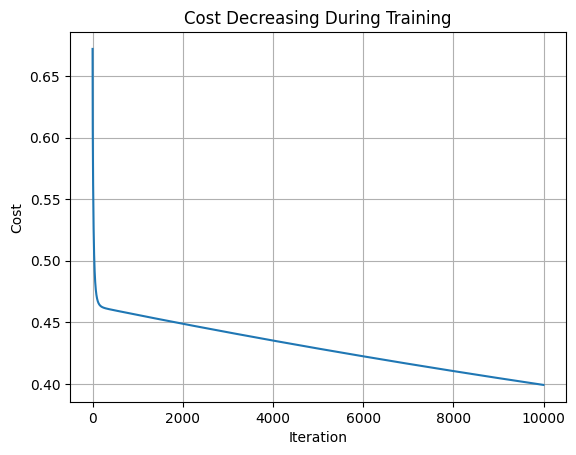

In [11]:
plt.plot(cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost Decreasing During Training")
plt.grid(True)
plt.show()

## Making Predictions

After training, the model outputs probabilities.

To convert probabilities into class labels, I use a threshold of 0.5.

- Probability >= 0.5 means class 1
- Probability < 0.5 means class 0

In [12]:
def predict(X, w, b):
   probabilities = sigmoid(np.dot(X,w)+b)
   probabilities = probabilities >=0.5
   
   return probabilities.astype(int)

In [13]:
predictions = predict(X, w_final, b_final)

accuracy = np.mean(predictions == y) * 100

print("Predictions:", predictions)
print("Actual labels:", y)
print("Accuracy:", accuracy)

Predictions: [0 0 0 0 1 1 1 1 1 1 0 0 1 1 1]
Actual labels: [0 0 0 1 1 1 0 0 1 1 0 0 1 1 1]
Accuracy: 80.0


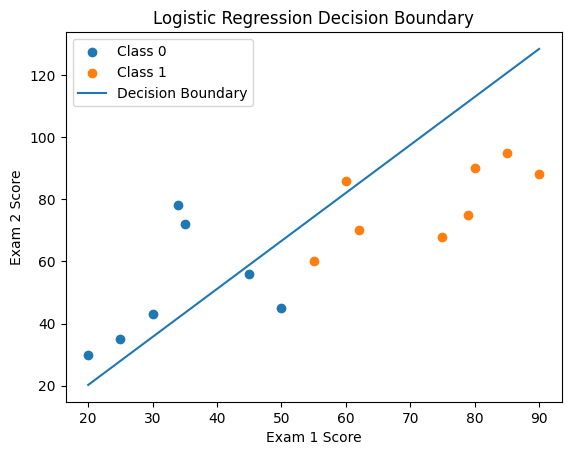

In [14]:
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], label="Class 0")
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], label="Class 1")

x_values = np.array([X[:, 0].min(), X[:, 0].max()])

y_values = -(w_final[0] * x_values + b_final) / w_final[1]

plt.plot(x_values, y_values, label="Decision Boundary")

plt.xlabel("Exam 1 Score")
plt.ylabel("Exam 2 Score")
plt.title("Logistic Regression Decision Boundary")
plt.legend()
plt.show()

## Summary

In this notebook, I implemented logistic regression from scratch.

Main ideas covered:

- Classification predicts categories instead of continuous values.
- Logistic regression uses the sigmoid function to output probabilities.
- Binary cross-entropy is used as the cost function.
- Gradient descent updates the parameters to reduce the cost.
- A threshold converts probabilities into final class predictions.
- The decision boundary separates the two classes.

This helped me understand how logistic regression works internally before using machine learning libraries like scikit-learn.